In [1]:
# import standard packages
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
from pathlib import Path
import dask.dataframe as dd
import cmocean
import xesmf as xe
import seaborn as sns
# import spatial packages
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rio
import seaborn as sns
import xarray as xr
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from dask.distributed import Client
from google.cloud import storage
import xskillscore as xs

try:
    import flox
except ImportError:
    print("[ACTEA_downscale] Warning: flox not installed - continuing without")

import sys
sys.path.append('../')
import ACTEA_gcs
import ACTEA_merge_datasets

In [2]:
# Settings for the script
sns.set_style("white")
actea_variables = ["uo","vo"]
time="2018-01-01"
coarsen_step = 1
lat_lon_ext = [360-173., 360-152., 54., 68.]
depth=5.0
frequency="monthly"

base_path=f"glorys_validation"
gcs = ACTEA_gcs.ACTEA_gcs(frequency)
gcs.setup_actea_google_storage()
if not Path(base_path).exists():
    Path(base_path).mkdir(parents=True)

### Load the Ba+SD downscaled ERA5 data
Load the final dataset after downscaling the coarsened ERA5 dataset.

In [3]:
ds_all_actea={}
for varname, iterations in zip(actea_variables, [0,0]):
    ds_all_actea[varname], ds_plotfile = ACTEA_merge_datasets.create_merged_ds(["test_glorys"], 
                                                            "GLORYS12V1",  
                                                            "surface", 
                                                            varname, 
                                                            "ssp585", 
                                                            "r1i1p1f1", 
                                                            depth,
                                                            iterations=iterations,
                                                            frequency=frequency)
    ds_all_actea[varname] = ds_all_actea[varname].assign_coords(lon=(np.mod(ds_all_actea[varname].lon, 360))).sortby("lon")

    print(f"ACTEA: {varname} dataset size in MB", ds_all_actea[varname][varname].size / (1024*1024))

ds_uo_actea = ds_all_actea["uo"] 
ds_vo_actea = ds_all_actea["vo"]

ds_uo_actea = (ds_uo_actea.assign_coords(lon=(np.mod(ds_uo_actea.lon, 360)))).sortby("lon")
ds_vo_actea = (ds_vo_actea.assign_coords(lon=(np.mod(ds_vo_actea.lon, 360)))).sortby("lon")

ds_uo_actea = ds_uo_actea.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))
ds_vo_actea = ds_vo_actea.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))


[ACTEA_merge_datasets] ssp585 uo (324, 217, 337)
ACTEA: uo dataset size in MB 22.59616470336914
[ACTEA_merge_datasets] ssp585 vo (324, 217, 337)
ACTEA: vo dataset size in MB 22.59616470336914


### Load the original GLORYS dataset
This dataset is stored from 1993 to 2019. The dataset is stored in the form of a netCDF file. The dataset
is generated and upload to GCS automatically when you run the downscaling using ´GLORYS12V1´ as the model. This dataset is
then coarsened and used as the input for the downscaling process. 

In [4]:
def load_glorys_datasets():
    ds_uo = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/uo/GLORYS12V1_r1i1p1f1_uo_surface_{depth}m_GLORYS12V1_full.nc", engine="h5netcdf")
    ds_vo = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/vo/GLORYS12V1_r1i1p1f1_vo_surface_{depth}m_GLORYS12V1_full.nc", engine="h5netcdf")
    ds_uo = (ds_uo.assign_coords(lon=(np.mod(ds_uo.lon, 360)))).sortby("lon")
    ds_vo = (ds_vo.assign_coords(lon=(np.mod(ds_vo.lon, 360)))).sortby("lon")

    return ds_uo.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])), ds_vo.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))

ds_uo_glorys, ds_vo_glorys = load_glorys_datasets()

print("GLORYS12V1 fine uo size in MB", ds_uo_glorys.uo.size / (1024*1024))
print("GLORYS12V1 fine vo size in MB", ds_vo_glorys.vo.size / (1024*1024))
print(f"Time range: {ds_uo_glorys.time.min().values} to {ds_uo_glorys.time.max().values}")


GLORYS12V1 fine uo size in MB 11.958240509033203
GLORYS12V1 fine vo size in MB 11.958240509033203
Time range: 1993-01-16T12:00:00.000000000 to 2019-12-16T12:00:00.000000000


In [5]:
def load_coarsened_glorys_datasets():
    ds_uo_coarse = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/uo/GLORYS12V1_r1i1p1f1_uo_surface_{depth}m_GLORYS12V1_coarsened_step_12.nc", engine="h5netcdf")
    ds_vo_coarse = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/vo/GLORYS12V1_r1i1p1f1_vo_surface_{depth}m_GLORYS12V1_coarsened_step_12.nc", engine="h5netcdf")
    ds_uo_coarse = (ds_uo_coarse.assign_coords(lon=(np.mod(ds_uo_coarse.lon, 360)))).sortby("lon")
    ds_vo_coarse = (ds_vo_coarse.assign_coords(lon=(np.mod(ds_vo_coarse.lon, 360)))).sortby("lon")
  #  return ds_uo_coarse.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])), ds_vo_coarse.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))
    return ds_uo_coarse, ds_vo_coarse


ds_uo_coarse, ds_vo_coarse = load_coarsened_glorys_datasets()
print("GLORYS12V1 coarse uas size in MB", ds_uo_coarse.uo.size / (1024*1024))
print("GLORYS12V1 coarse vas size in MB", ds_vo_coarse.vo.size / (1024*1024))
print(f"Time range: {ds_uo_coarse.time.min().values} to {ds_uo_coarse.time.max().values}")

GLORYS12V1 coarse uas size in MB 0.15851211547851562
GLORYS12V1 coarse vas size in MB 0.15851211547851562
Time range: 1993-01-16T12:00:00.000000000 to 2019-12-16T12:00:00.000000000


In [6]:
ds_vo_coarse=ds_vo_coarse.sel(time=slice("2015-01-01","2021-01-01"), lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_coarse= ds_uo_coarse.sel(time=slice("2015-01-01","2021-01-01"), lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3])).chunk({"time":-1, "lat":-1, "lon": -1})
ds_uo_coarse = ds_uo_coarse.resample(time="1M").mean()
ds_vo_coarse = ds_vo_coarse.resample(time="1M").mean()

/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/xarray/groupers.py:403: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/dask/array/numpy_compat.py:60: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/home/tk/.conda/envs/opendrift/envs/actea/lib/python3.11/site-packages/dask/array/num

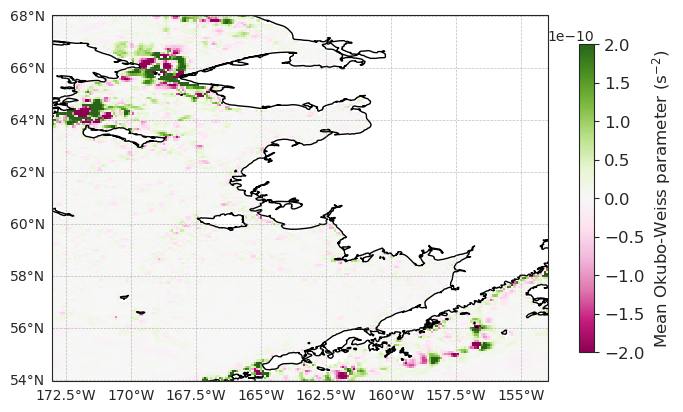

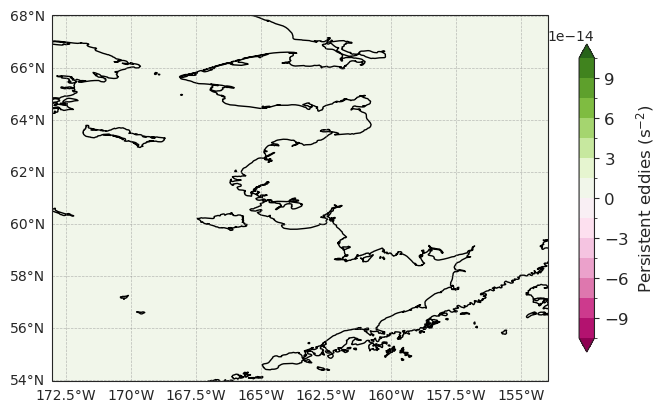

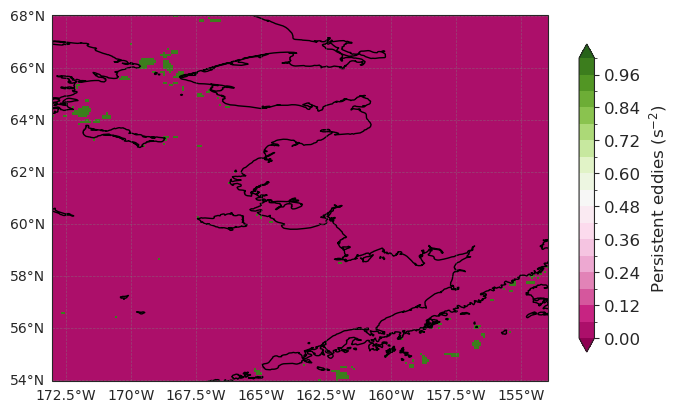

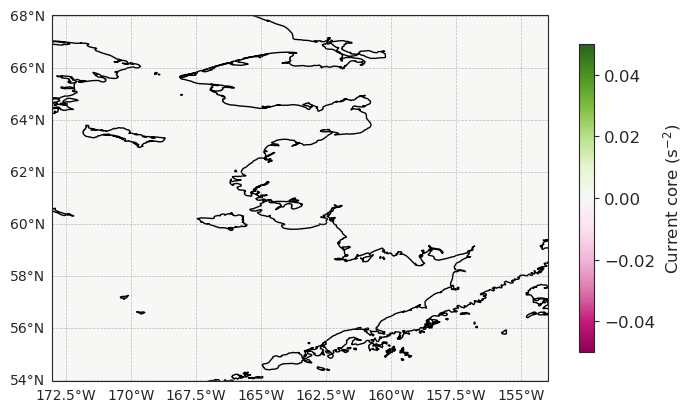

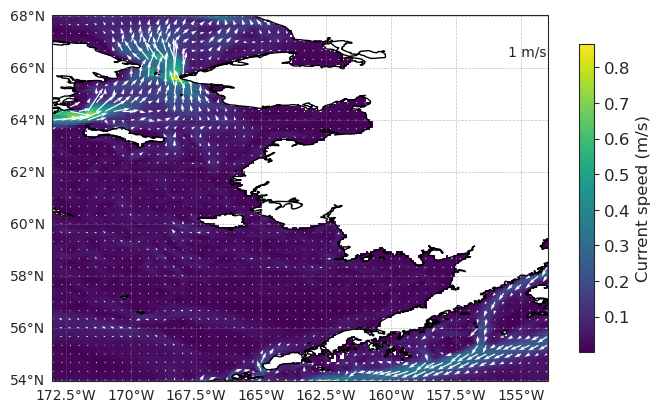

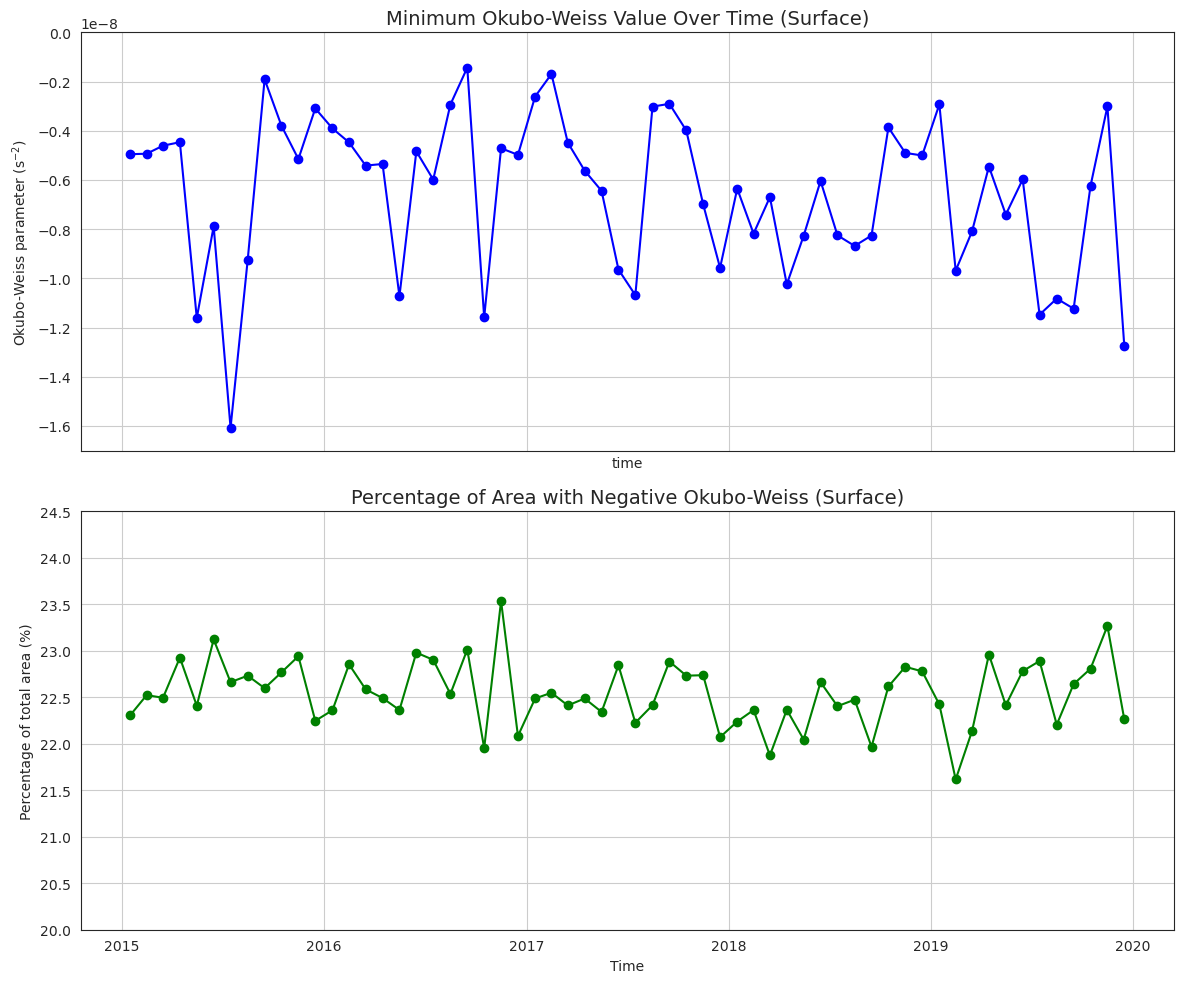

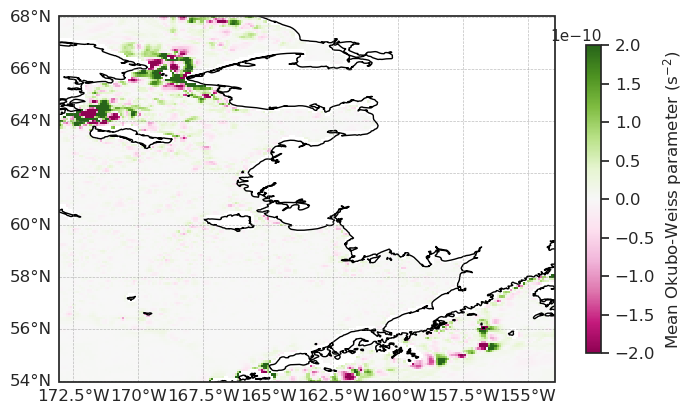

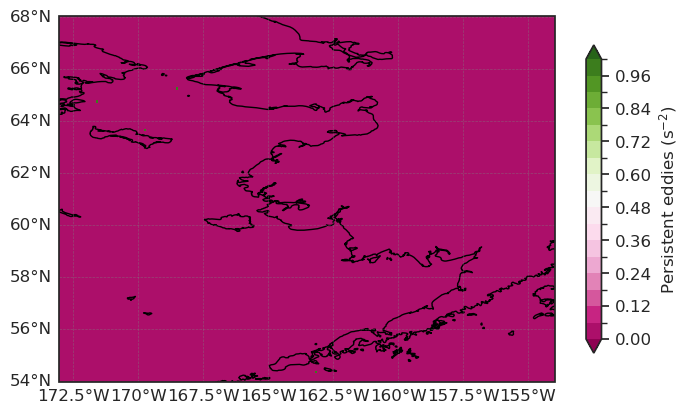

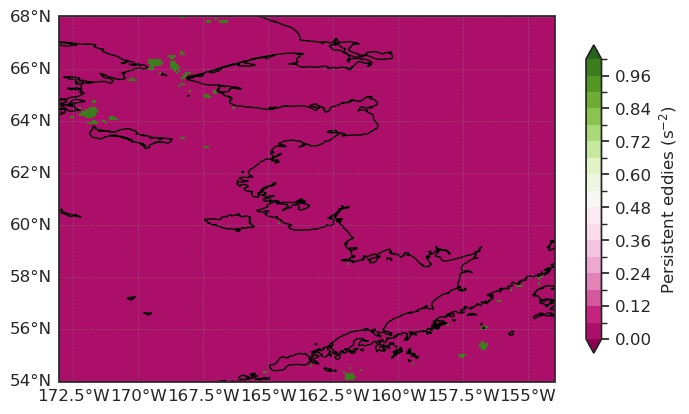

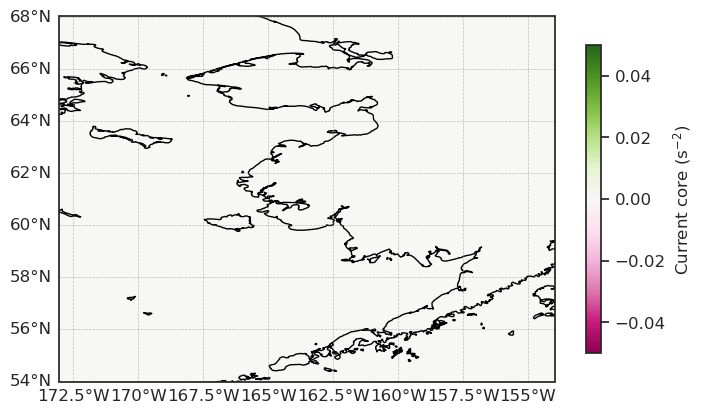

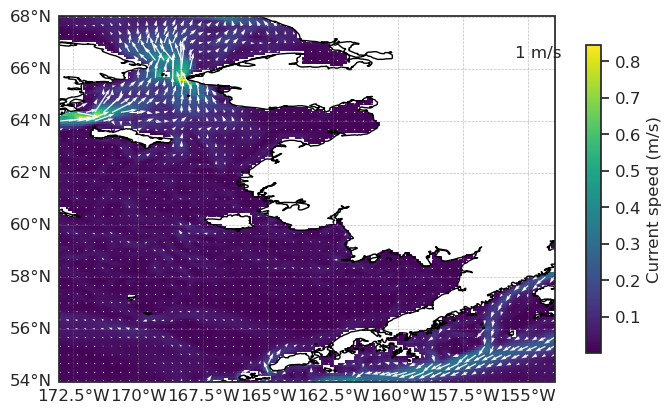

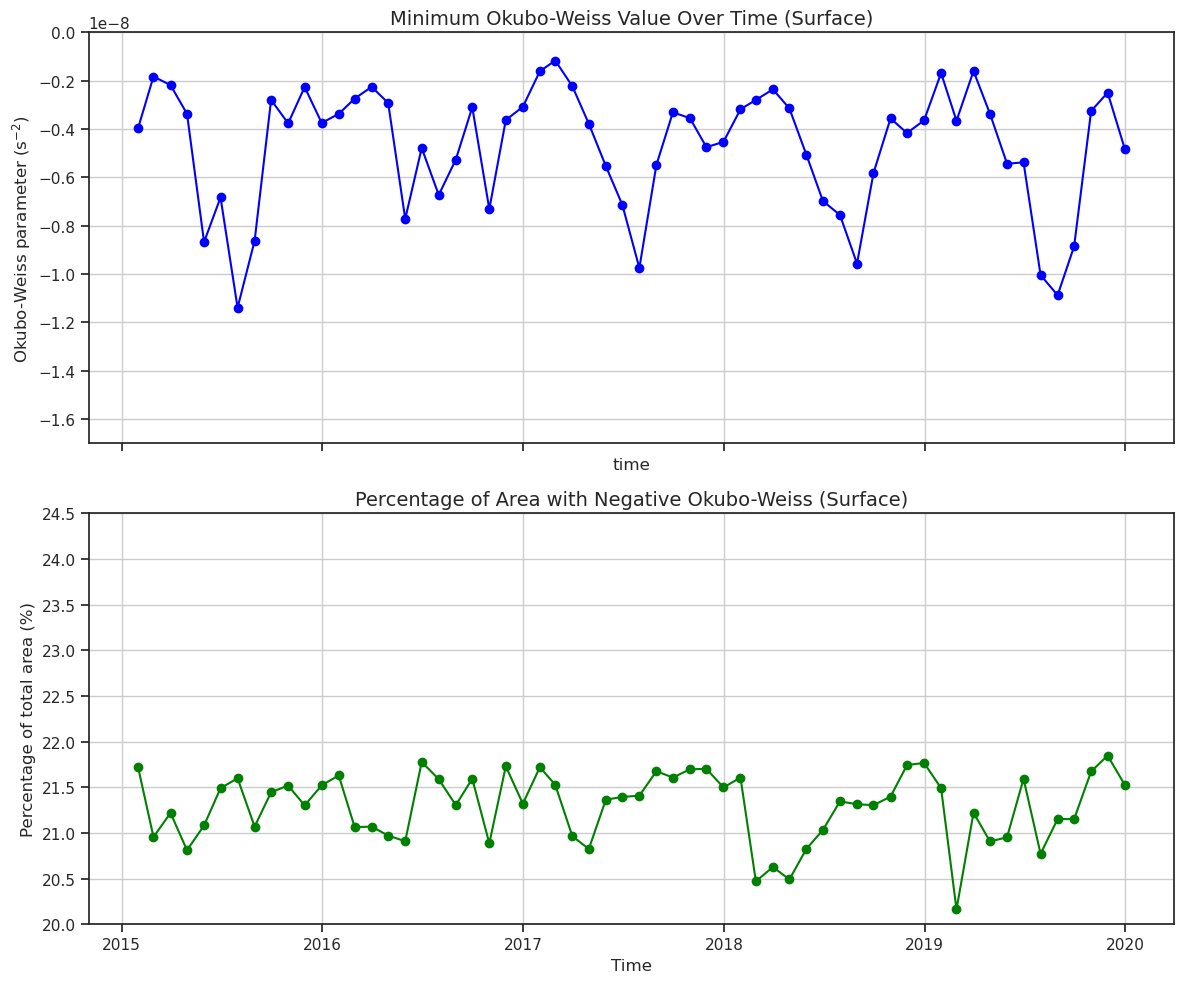

In [7]:
# Calculate the Okubo-Weiss parameter    
import ACTEA_Okubo_Weiss

ds_g = xr.merge([ds_uo_glorys, ds_vo_glorys])
ds_a = xr.merge([ds_uo_actea, ds_vo_actea])

for ds, postfix in zip([ds_g, ds_a], ["glorys", "actea"]):
    ds = ds.rename({"uo": "u", "vo": "v"})
    ACTEA_Okubo_Weiss.plot_okubo_weiss(ds, time_idx=None, depth_idx=f"{depth}", postfix=postfix)
    ACTEA_Okubo_Weiss.plot_okubo_weiss_timeseries(ds, postfix=postfix)
    #ACTEA_Okubo_Weiss.plot_okubo_weiss_3d(ds.mean(dim="time"), time_idx=None, postfix=postfix)
